Worksheet 1
Image Compression and Decompression using PCA

In [2]:
from google.colab import files
uploaded = files.upload()

Saving image.png to image.png


Import Required Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

%matplotlib inline

Load and Prepare Image


We resize for computational efficiency.
```
# This is formatted as code
```



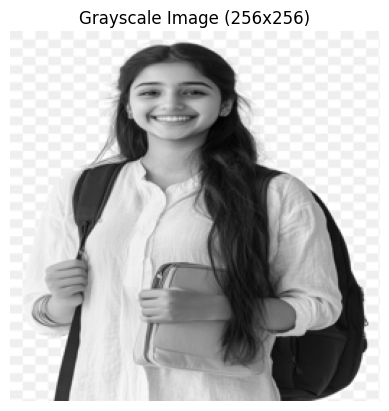

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load correct file
image = Image.open("image.png")

# Convert to grayscale
image_gray = image.convert("L")

# Resize for PCA efficiency
image_gray = image_gray.resize((256, 256))

X = np.array(image_gray, dtype=np.float64)

plt.imshow(X, cmap='gray')
plt.title("Grayscale Image (256x256)")
plt.axis("off")
plt.show()

Mean Centering (Standardization Step)

In [8]:
# Compute mean across columns
mean = np.mean(X, axis=0)

# Center the data
X_centered = X - mean

Covariance Matrix

In [9]:
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (256, 256)


Eigen Decomposition

We use eigh because covariance matrix is symmetric.

In [10]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [12]:
# Sort in descending order
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

Explained Variance Analysis

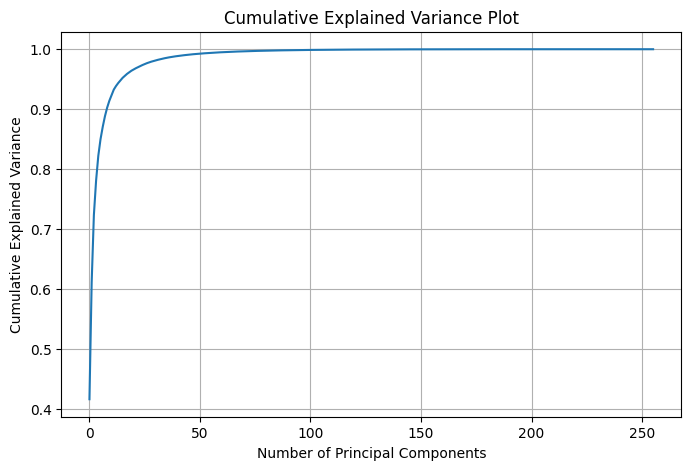

In [13]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

In [14]:
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components for 95% variance:", k_95)

Number of components for 95% variance: 16


Reconstruction Function

In [15]:
def reconstruct_image(k):
    W = eigenvectors[:, :k]

    X_reduced = np.dot(X_centered, W)
    X_reconstructed = np.dot(X_reduced, W.T) + mean

    return X_reconstructed

Compare 4 Different Principal Component Values

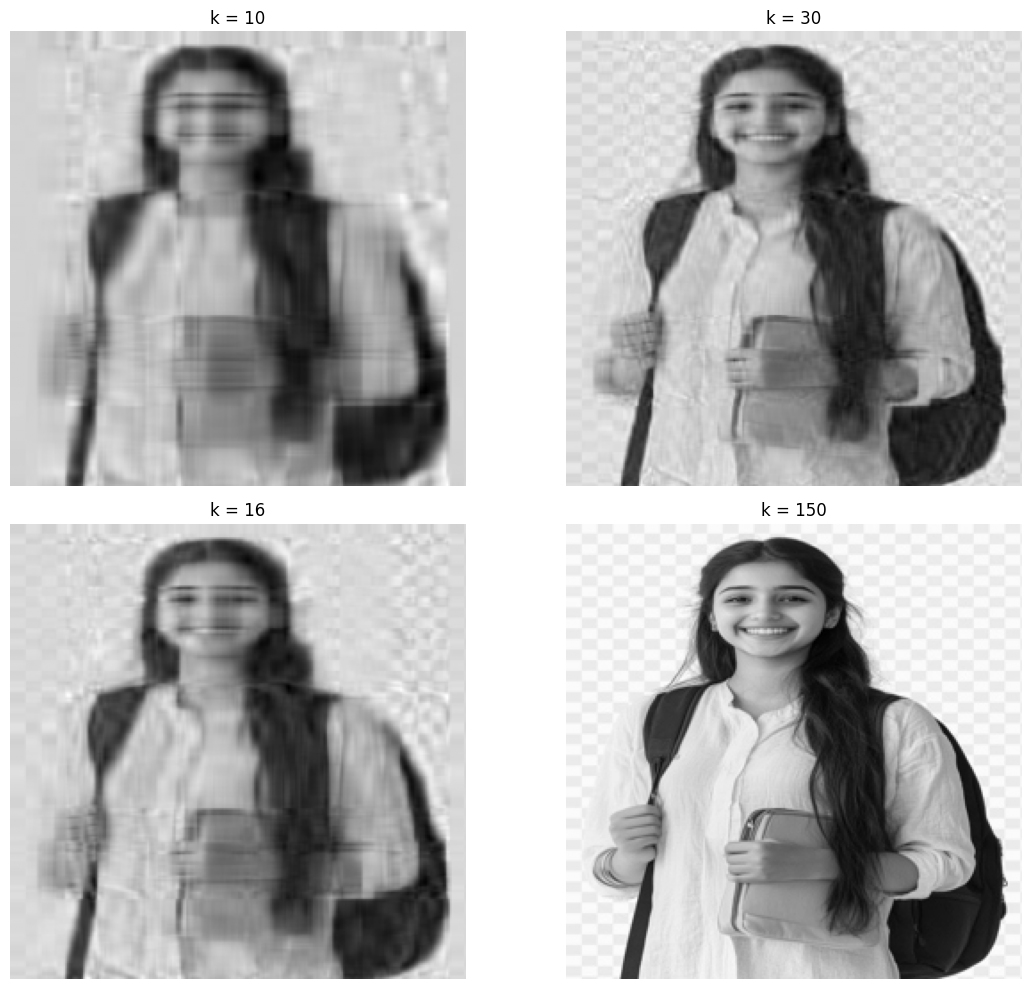

In [16]:
k_values = [10, 30, k_95, 150]

plt.figure(figsize=(12,10))

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(k)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Compare Original vs Best Reconstruction

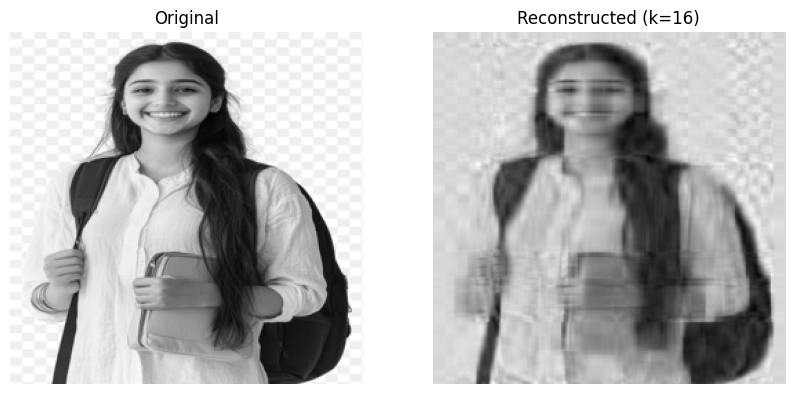

In [17]:
best_reconstruction = reconstruct_image(k_95)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_reconstruction, cmap='gray')
plt.title(f"Reconstructed (k={k_95})")
plt.axis("off")

plt.show()